# Quantum Error Mitigation Project Overview

## 📘 1. Introduction
In this notebook, we present our semester-long project focused on **Quantum Error Mitigation using Machine Learning**. Our work centers around evaluating, reproducing, and extending results from a state-of-the-art research paper:

> **Paper Title**: Machine Learning for Practical Quantum Error Mitigation  
> **Authors**: Haoran Liao, Derek S. Wang, Iskandar Sitdikov, et al.  
> **arXiv**: [2309.17368v2](https://arxiv.org/abs/2309.17368v2)

This report is structured to walk through the literature review, implementation, new experimentation, and results analysis.

---

## 📚 2. Literature Review

### Primary Paper Studied
- **Machine Learning for Practical Quantum Error Mitigation** (Liao et al., 2023) — introduced ML-QEM models (Random Forest, GNN, etc.) to reduce mitigation overhead and match or outperform ZNE.

### Additional Papers
- **A MACHINE LEARNING-BASED ERROR MITIGATION APPROACH FOR RELIABLE SOFTWARE DEVELOPMENT ON IBM’S QUANTUM COMPUTERS**  
- **KAN: Kolmogorov Arnolds Network**

> we also provided our mid term paper presentation slides
---

## 🔧 3. Reproducing the Paper's Experiments

### Repository Used
We cloned the authors’ official repo:
```
git clone https://github.com/qiskit-community/ml-qem
```

### Experiments Recreated
- **Random Circuit Benchmarks** (varied qubit counts and depths, but major work done on 10 qubit circuits)
- **Ising circuits** (Preliminary testing of models on 4q Ising circuits)

### ML Models Benchmarked (as in paper)
- Linear Regression (OLS)
- Multi-Layer Perceptron (MLP)
- Random Forest (RF)
- Graph Neural Networks (GNN)

---

## 🚀 4. Extending with Custom Models

### A. Kolmogorov–Arnold Networks (KAN)  
Adapted for regression on circuit features, allowing highly expressive function modeling.

### B. Convolutional Neural Network (CNN)
Encoded quantum circuits as images, applying CNN layers to capture spatial patterns.

### C. Graph Attention Network (GAT)  
Utilized circuit graph structure with attention mechanisms to enhance ideal value estimation.

### D. Graph Convolutional Network (GCN)  
Applied message-passing over circuit graphs to aggregate neighborhood information for expectation value prediction.

### E. Graph Kolmogorov–Arnold Network (GKAN)  
Integrated KAN modules within a GNN framework to enable highly non-linear transformations over circuit graph embeddings.

### F. Recurrent neural network (RNN)
Encoded quantum circuits as sequential data, applying RNN layers to capture temporal dependencies and gate-order dynamics.

### G. Artificial neural network (ANN)
Flattened quantum circuit representations into fixed-size feature vectors, applying dense layers in ANN to learn abstract patterns from circuit structure.

### H. XGBoost
Transformed quantum circuit features into tabular format, using XGBoost to model complex nonlinear relationships with gradient-boosted decision trees.

### I. Random Forest
Converted quantum circuits into structured feature vectors, leveraging Random Forest to capture decision boundaries through ensemble averaging of multiple trees.


### Comparison Criteria
- Accuracy of mitigation
- Generalization to unseen circuits
- Inference speed (ML vs ZNE)

---

## 🔄 5. Updating Noise Models

### 🐛 Problem with Previous Approach
The original paper relied on outdated and less representative noise models like `FakeLima`, limiting the realism and generalizability of results.

### ✅ Our Improvements
- Adopted the real-device backend **`ibm_brisbane`** for up-to-date and hardware-accurate noise characteristics.
- Integrated Qiskit’s `NoiseModel` class to gain fine-grained control over simulated noise (decoherence, gate errors, and readout noise).
- Simulated realistic quantum drift and variability across runs to reflect hardware fluctuations.
- Applied these enhanced noise models in both simulation-based training and real-device evaluation, improving robustness and fidelity of learned models.

---

## 🧾 6. Dataset Generation

The `data-gen` folder forms the core of our simulation and data preparation pipeline. It supports training of **frequency-based**, **graph-based**, and **CNN-based** models.

In parallel, we created a **`hardware/`** folder to incorporate real hardware noise from the `ibm_brisbane` backend into graph-based models. This enabled a deeper comparison of **GNN**, **GAT**, and **GKAN** models using realistic calibration data and circuit mappings.

---

## 📂 Project Structure Overview (with Flow)

```text
             ┌────────────────┐
             │  data-gen/     │
             │  ───────────── │
             │  - Generator   │
             │  - Simulator   │
             │  - ZNE         │
             │  - Converter   │
             └─────┬──────────┘
                   │
       ┌───────────┼───────────────────────────┐
       │           │                           │
┌──────▼──────┐  ┌──▼────┐         ┌───────────▼────────────┐
│ freq/       │  │ cnn/  │         │ graph/                 │
│ Models like │  │ CNN   │         │ GNN Encoding           │
│ OLS, MLP    │  │ Models│         └────────────┬───────────┘
└─────────────┘  └───────┘                      │
                                          ┌─────▼─────────────────┐
                                          │ hardware/ (ibm data)  │
                                          │ - Calibration-aware   │
                                          │   GCN, GAT, GKAN      │
                                          └───────────────────────┘
```


## 📁 `pipeline/src/DATA_GEN/` File Overview

The `DATA_GEN/` folder is responsible for generating quantum circuits, simulating them, and transforming them into formats suitable for machine learning.

| File            | Main Class/Function | Purpose                                                                 |
|-----------------|---------------------|-------------------------------------------------------------------------|
| `generator.py`  | `Generator`         | Synthesizes quantum circuits with configurable depth, qubit count, and observables. |
| `simulator.py`  | `Simulator`         | Simulates both noisy and ideal executions using Qiskit simulators.     |
| `zne.py`        | `ZNE`               | Applies Zero Noise Extrapolation to reduce noise-induced bias in expectation values. |
| `converter.py`  | `Converter`         | Converts circuits into ML-friendly formats: graphs (PyG), CNN-like matrices, frequency vectors. |
| `extractor.py`  | `Extractor`         | Extracts structural and statistical features from circuits and circuit graphs. |
| `util.py`       | -                   | Utility functions for formatting, logging, and backend interfacing.     |
| `main.ipynb`    | -                   | Jupyter notebook demonstrating complete pipeline from generation to ML input creation. |

---

## 📁 `src/QEM/` File Overview

The `QEM/` folder focuses on training Graph Neural Networks (GNNs) on depth-wise qubit data, providing insights and results for quantum error mitigation. It includes various components for model creation, training, evaluation, and preprocessing.

| File              | Purpose |
|-------------------|---------|
| `base_models.py`  | Contains simple classes like `SimpleGNN`, `SimpleTransformer`, `MLP`, etc., that serve as building blocks for more complex models. |
| `evaluator.py`    | Provides functionality to plot and calculate the performance of the trained models. |
| `preprocessor.py` | Reads CSV files and converts the data into tensors suitable for training. |
| `trainer.py`      | Contains the core code for training GNN models on the prepared dataset. |
| `evaluate.py`     | Evaluates the performance of the trained GNN models. |
| `main.ipynb`      | Jupyter notebook that ties everything together, calling the necessary scripts and presenting results in a user-friendly manner. |


---

## 🧠 `hardware/` Folder Overview

The `hardware/` folder focuses on **real-device-aware mitigation** using IBM’s `ibm_brisbane` backend. The workflow builds on the PyTorch Geometric (PyG) format and enhances circuits with calibration noise, readout error, and mapping data.

| File              | Purpose |
|-------------------|---------|
| `data_gen.ipynb`  | Converts transpiled circuits into PyG graphs using actual calibration data and coupling maps from `ibm_brisbane`. Each node (qubit) is enriched with physical calibration features. |
| `model_study.ipynb` | Benchmarks various GNN architectures (GCN, GAT, and GKAN) for error mitigation on real-device-mapped circuits. Compares inference accuracy, robustness, and calibration-awareness. |


## 🧾 7. Dataset Preprocessing

The raw quantum circuit data was transformed into multiple machine learning-friendly representations, each tailored for specific model architectures. All approaches incorporated custom Qiskit noise models grounded in realistic hardware characteristics.

Simulations were consistently performed using **statevector simulators** to avoid sampling-induced randomness, ensuring high-precision expectation values. For noisy simulations, **8192 shots or more** were used to approximate realistic quantum hardware behavior. Additionally, the simulation backend supports **GPU-accelerated statevector simulation** on compatible systems, enabling faster evaluation of large or deep circuits.

Multiple **Zero Noise Extrapolation (ZNE)** methods were implemented for benchmarking, including:
- **Linear extrapolation**
- **Richardson extrapolation**
- Others supported via modular plugin-like architecture

The ZNE framework is designed to be highly **extensible**, allowing new mitigation strategies to be added with minimal effort.

---

### 1. Frequency-Based Features (for RF, OLS, MLP)

This method is inspired by the original paper and represents circuits as vectors of gate frequencies and discretized gate parameters.

- **Gate Frequency Counting**: Counts how many times each gate appears.
- **Parameter Discretization**: Gate parameters (like rotation angles) are binned into intervals and counted.
- **Flexible Configurations**:
  - Per-gate kind frequency vs. combined parameter frequency.
  - Choice of bin size and parameter aggregation.

```python
features = {
    'gate_counts': [...],
    'observable': [...],
    'noisy_expectation': [...],
    'readout_errors': [...]
}
```

---

### 2. CNN-Based Encoding

Quantum circuits were encoded into image-like tensors to leverage spatial pattern learning using Convolutional Neural Networks (CNNs).

- **Tensor Dimensions**:
  - **Height**: Circuit depth
  - **Width**: Number of qubits
  - **Channels**: One-hot encoding of gate types

This encoding captures the temporal and spatial arrangement of gates, modeling the circuit as a time-series image.

---

### 3. Graph-Based Representations (for GCN, GAT, GKAN)

Two graph-based strategies were used to represent circuit structure:

#### a. Logical Graphs

- **Nodes**: Represent individual gates  
  - Features include:
    - Gate type (one-hot encoded)
    - Gate role (master/slave)
    - Gate parameters (e.g., rotation angles)
- **Edges**: Represent connections between gates based on application order in the circuit


In [ ]:
import os
os.chdir("pipeline/src/DATA_GEN/")

from util import *
from simulator import QuantumCircuitSimulator
from converter import CircuitConverter
from zne import ZNESimulator
from generator import QuantumGenerator
from extractor import QuantumGraphExtractor


# Create an instance of QuantumGenerator with desired parameters.
qgen = QuantumGenerator(
    n_qubits=10,
    depth=(2, 3, 2),         # Depth values: 4, 6, 8
    circuits_per_depth=1,
    shots=8192,
    scale_factors=[1.0, 2.0, 3.0],
    observable_mode="fixed",   # Use random observables ("X", "Y", or "Z")
    fixed_pauli="ZZZZZZZZZZ",         # If fixed mode is used, provide a string e.g. "XYZZZ"
    optimization_level=0,
    transpile_backend=None,   # Uses default GenericBackendV2 if not provided.
    conversion_type=["graph", "cnn", "freq"],  # List of conversions, options: 'graph', 'freq', 'cnn' etc.
    save=False, # Right now turning off save, but if u wish, provide suitable directory to save data
    filename="../../data/raw_data" # Additional info like nqbit, depth_params, circuits_per_depth are appended to file-name
)

# Generate the data and store it in a DataFrame.
df = qgen.generate_data(output_format='csv')
print("Generated Data:")
print(df)

#### b. Hardware-Aware Graphs

- **Nodes**: Represent physical qubits, gates, measurement qubits  
- **Edges**: Represent actual two-qubit gates from the transpiled circuit  
  - **Edge Attributes**:
    - Gate timing  
    - Gate error rate (from calibration data)

These graphs were built using real hardware information from the **IBM Brisbane** backend, incorporating calibration data and coupling maps to reflect actual noise and device topology.

Transpiling circuits using `ibm_brisbane` as the backend introduces **ancilla qubits** for routing and error correction, expanding the circuit to the full 127-qubit hardware graph. As a result, the transpiled circuit often exceeds **32 qubits**, making **classical simulation infeasible**. 

To overcome this, we implemented a **qubit mapping scheme** that tracks the original-to-transpiled qubit correspondence. This allowed us to extract a **reduced circuit** involving only the active qubits actually used in computation—typically under 32—making simulation tractable.

However, this mapping also introduces a key limitation:  
Due to the presence of ancilla qubits and changes in qubit indexing, we can no longer reliably assign **sparse observable labels** like `ZIIII` or `IZIII`, which were initially meant to provide diverse prediction targets for richer learning. Instead, we are limited to **joint expectation values** (e.g., ⟨ZZZZZ...⟩ across all qubits), since these are the only consistent observables post-transpilation.

While this simplifies the prediction task, it **reduces the diversity of training labels**, weakening the model’s ability to generalize from partial observables. The initial goal of leveraging multiple sparse Pauli terms to provide the neural network with more granular circuit-level information had to be abandoned in favor of simulation feasibility.

Sample Circuit:
![results/sample_circuit.png](results/sample_circuit.png)


In [6]:
# ------------------------- IMPORTS -------------------------
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_aer.noise import NoiseModel
from qiskit_aer import AerSimulator
from qiskit.circuit.random import random_circuit
from qiskit import transpile, QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.converters import circuit_to_dag
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.instruction import Instruction

import pandas as pd
import numpy as np
import torch
from torch_geometric.data import Data

import re
import os
from datetime import datetime

# ------------------------- INITIAL SETUP -------------------------
service = QiskitRuntimeService(name="Aniket")
backend = service.backend("ibm_brisbane")
noise_model = NoiseModel.from_backend(backend)

calib_path = "D:/heisen/IITM/IITM studies/4th year/sem 8/DA6300/QML blackwater/A-Comprehensive-Study-of-ML-Techniques-for-Quantum-Error-Mitigation/hardware/ibm_brisbane_calibrations_2025-04-05T06_27_38Z.csv" #Give path to ibm_brisbane callibration data

# ------------------------- FUNCTIONS -------------------------
def extract_active_physical_qubits(transpiled_circ):
    return sorted({
        qubit._index
        for instr in transpiled_circ.data
        for qubit in instr.qubits
    })

def create_virtual_circuit(transpiled_circ, hardware_to_virtual):
    num_virtual_qubits = len(hardware_to_virtual)
    qr_virtual = QuantumRegister(num_virtual_qubits, 'q')
    cr_virtual = ClassicalRegister(num_virtual_qubits, 'c')
    reduced_circ = QuantumCircuit(qr_virtual, cr_virtual)

    for instr in transpiled_circ.data:
        new_qargs = [qr_virtual[hardware_to_virtual[q._index]] for q in instr.qubits]
        new_cargs = [cr_virtual[transpiled_circ.find_bit(c).index] for c in instr.clbits]
        reduced_circ.append(instr.operation, new_qargs, new_cargs)

    return reduced_circ

def simulate_expectation_values(circuit, noise_model=None, shots=10000):
    n_qubits = circuit.num_qubits
    qc = circuit.remove_final_measurements(inplace=False)
    for q in range(n_qubits):
        label = ['I'] * n_qubits
        label[q] = 'Z'
        op = SparsePauliOp.from_list([("".join(label), 1.0)])
        qc.save_expectation_value(op, qubits=list(range(n_qubits)), label=f"z{q}")
    joint_label = ['Z'] * n_qubits
    joint_op = SparsePauliOp.from_list([("".join(joint_label), 1.0)])
    qc.save_expectation_value(joint_op, qubits=list(range(n_qubits)), label="joint_z")
    
    sim = AerSimulator(noise_model=noise_model, method="statevector")
    if noise_model:
        circuit.measure_all(inplace=True)
        result = sim.run(circuit, shots=shots).result()
        counts = result.get_counts()
        z_expect = []
        for q in range(n_qubits):
            z = 0
            for bitstring, count in counts.items():
                bit = bitstring[::-1][q]
                z += count if bit == '0' else -count
            z_expect.append(z / shots)
        joint = 0
        for bitstring, count in counts.items():
            parity = sum(int(bitstring[::-1][q]) for q in range(n_qubits)) % 2
            eigenvalue = (-1) ** parity
            joint += count * eigenvalue
        return z_expect, joint / shots
    else:
        result = sim.run(qc).result()
        z_expect = [result.data(0)[f"z{q}"] for q in range(n_qubits)]
        joint = result.data(0)["joint_z"]
        return z_expect, joint

def extract_dag_data(dag):
    nodes, edges, edge_features, node_to_uid = {'gates': {}, 'input': {}, 'output': {}}, {}, {}, {}
    def idx(bit):
        return getattr(bit, 'index', getattr(bit, '_index', bit[1] if isinstance(bit, tuple) else None))
    for i, node in enumerate(dag.topological_nodes()):
        uid = f"node_{i}"
        node_to_uid[node] = uid
        qargs = [idx(q) for q in getattr(node, 'qargs', [])]
        cargs = [idx(c) for c in getattr(node, 'cargs', [])]
        if hasattr(node, 'op'):
            nodes['gates'][uid] = {'type': node.op.name, 'qargs': qargs, 'cargs': cargs}
        else:
            cat = 'input' if 'In' in type(node).__name__ else 'output'
            nodes[cat][uid] = {'type': type(node).__name__, 'qargs': qargs, 'cargs': cargs}
    for i, (src, dst, wire) in enumerate(dag.edges()):
        eid = f"edge_{i}"
        edges[eid] = (node_to_uid[src], node_to_uid[dst])
        edge_features[eid] = idx(wire)
    return nodes, edges, edge_features

def parse_calibration_csv(file_path, active_qubits, hardware_to_virtual):
    df = pd.read_csv(file_path)
    cols = [
        'T1 (us)', 'T2 (us)', 'Frequency (GHz)', 'Anharmonicity (GHz)',
        'Readout assignment error ', 'Prob meas0 prep1 ',
        'Prob meas1 prep0 ', 'Readout length (ns)'
    ]
    qubit_info = {
        hardware_to_virtual[q]: {col: row[col] for col in cols}
        for _, row in df.iterrows() if (q := row["Qubit"]) in hardware_to_virtual
    }
    gate_errors = {g: {} for g in ["id", "rz", "sx", "x", "ecr"]}
    for _, row in df.iterrows():
        if (q := row["Qubit"]) not in hardware_to_virtual: continue
        vq = hardware_to_virtual[q]
        gate_errors["id"][vq] = row["ID error "]
        gate_errors["rz"][vq] = row["Z-axis rotation (rz) error "]
        gate_errors["sx"][vq] = row["√x (sx) error "]
        gate_errors["x"][vq] = row["Pauli-X error "]
        for conn, val in re.findall(r'(/d+_/d+):([/d/.]+)', str(row["ECR error "])):
            if all(int(x) in hardware_to_virtual for x in conn.split('_')):
                vp = tuple(sorted(hardware_to_virtual[int(x)] for x in conn.split('_')))
                gate_errors["ecr"].setdefault(vp, {})["error"] = float(val)
        for conn, val in re.findall(r'(/d+_/d+):([/d/.]+)', str(row["Gate time (ns)"])):
            if all(int(x) in hardware_to_virtual for x in conn.split('_')):
                vp = tuple(sorted(hardware_to_virtual[int(x)] for x in conn.split('_')))
                gate_errors["ecr"].setdefault(vp, {})["Gate time"] = float(val)
    return qubit_info, gate_errors

def update_nodes_with_errors(nodes, gate_errors):
    for nid, node in nodes["gates"].items():
        t, q = node["type"], node["qargs"]
        if t in {"rz", "sx", "x"} and q:
            node["error"] = gate_errors.get(t, {}).get(q[0], 0.0)
        elif t == "ecr" and len(q) == 2:
            node["error"] = gate_errors["ecr"].get(tuple(sorted(q)), {}).get("error", 0.0)
        else:
            node["error"] = 0.0
    return nodes

def update_edge_features(edge_features, qubit_info):
    return {
        eid: {"qubit_id": q, "qubit_info": qubit_info.get(q, {})}
        for eid, q in edge_features.items()
    }

def build_gnn_data(nodes, edges, edge_features, gate_errors, qubit_info, backend,
                   z_noisy, joint_noisy, z_ideal, joint_ideal, hardware_to_virtual):
    types = sorted(set(backend.configuration().basis_gates + ["measure", "DAGInNode", "DAGOutNode"]))
    all_nodes = {**nodes["gates"], **nodes["input"], **nodes["output"]}
    node_names = list(all_nodes)
    node_to_idx = {name: i for i, name in enumerate(node_names)}

    def one_hot(t, T): return [int(t == s) for s in T]
    def node_features(node):
        return one_hot(node["type"], types) + [
            len(node.get("qargs", [])), 
            len(node.get("cargs", [])), 
            node.get("error", 0.0), 
            0.0
        ]

    X = np.array([node_features(all_nodes[n]) for n in node_names])
    edge_index = np.array([[node_to_idx[s], node_to_idx[d]] for s, d in edges.values()]).T

    keys = [
        'T1 (us)', 'T2 (us)', 'Frequency (GHz)', 'Anharmonicity (GHz)',
        'Readout assignment error ', 'Prob meas0 prep1 ',
        'Prob meas1 prep0 ', 'Readout length (ns)'
    ]
    edge_attr = np.array([
        [feat["qubit_info"].get(k, 0.0) for k in keys]
        for feat in edge_features.values()
    ])

    # Use sentinel value -2.0 instead of 0.0 for unused qubits
    sentinel = -2.0
    full_z_noisy = np.full(127, sentinel)
    full_z_ideal = np.full(127, sentinel)
    for hw, vq in hardware_to_virtual.items():
        full_z_noisy[hw] = z_noisy[vq]
        full_z_ideal[hw] = z_ideal[vq]

    mapping_tensor = torch.full((127,), -1, dtype=torch.long)
    for hw, vq in hardware_to_virtual.items():
        mapping_tensor[hw] = vq

    return Data(
        x=torch.tensor(X, dtype=torch.float),
        edge_index=torch.tensor(edge_index, dtype=torch.long),
        edge_attr=torch.tensor(edge_attr, dtype=torch.float),
        z_noisy=torch.tensor(full_z_noisy, dtype=torch.float),
        z_ideal=torch.tensor(full_z_ideal, dtype=torch.float),
        joint_noisy=torch.tensor(joint_noisy, dtype=torch.float),
        joint_ideal = torch.tensor(joint_ideal, dtype=torch.float),
        mapping=mapping_tensor
    )

# ------------------------- GENERATE DATA -------------------------
from tqdm.notebook import tqdm
dataset = []
num_samples = 1  # Change as needed

for i in tqdm(range(num_samples), desc="Sample Generating"):
    circ = random_circuit(10, 5, max_operands=2, measure=True, seed=i)
    transpiled = transpile(circ, backend=backend)
    active_physical = extract_active_physical_qubits(transpiled)
    hardware_to_virtual = {hw: i for i, hw in enumerate(active_physical)}
    reduced = create_virtual_circuit(transpiled, hardware_to_virtual)
    z_ideal, joint_ideal = simulate_expectation_values(reduced, None)
    z_noisy, joint_noisy = simulate_expectation_values(reduced.copy(), noise_model)
    dag = circuit_to_dag(reduced)
    nodes, edges, edge_features = extract_dag_data(dag)
    qubit_info, gate_errors = parse_calibration_csv(calib_path, active_physical, hardware_to_virtual)
    nodes = update_nodes_with_errors(nodes, gate_errors)
    edge_features = update_edge_features(edge_features, qubit_info)
    data = build_gnn_data(nodes, edges, edge_features, gate_errors, qubit_info, backend,
                          z_noisy, joint_noisy, z_ideal, joint_ideal, hardware_to_virtual)
    dataset.append(data)

# ------------------------- SAVE DATA -------------------------
# timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
# save_path = f"gnn_dataset_{timestamp}.pt"
# torch.save(dataset, save_path)
# print(f"/n📁 Dataset saved to: {save_path}")


Sample Generating:   0%|          | 0/1 [00:00<?, ?it/s]

### 📊 GNN Hardware Data Feature Explanation

#### 🔹 Node Features (`data.x`)
Each node represents either:
- A quantum gate (like `rz`, `sx`, `x`, `ecr`, or `measure`)
- A special DAG input/output node (`DAGInNode`, `DAGOutNode`)

**Each node's feature vector includes:**

1. **One-hot encoding of gate type**
   - Encoded over: `basis_gates + ["measure", "DAGInNode", "DAGOutNode"]`
   - Example: If `basis_gates = ["rz", "sx", "x", "ecr"]`, then one-hot vector length is 7.
   - For example: `rz` → `[1, 0, 0, 0, 0, 0, 0]`

2. **Number of qubits used** – `1` for single-qubit gates, `2` for two-qubit gates, etc.

3. **Number of classical bits used** – Useful for measurement gates

4. **Gate error rate** – Taken from the calibration data (based on virtual-to-physical mapping)

5. **Gate execution time** – Currently set to `0.0` as a placeholder (non-zero for ECR Gates)

---

#### 🔹 Edge Index (`data.edge_index`)
- Represents a directed edge between nodes in the DAG
- Shape is `[2, num_edges]`
- Encodes gate execution order and qubit flow

---

#### 🔹 Edge Attributes (`data.edge_attr`)
Each edge corresponds to a virtual qubit wire and carries calibration info for that qubit.

Each edge has these 8 features:
1. T1 time (in microseconds)
2. T2 time (in microseconds)
3. Frequency (GHz)
4. Anharmonicity (GHz)
5. Readout assignment error
6. Probability of measuring 0 when prepared in 1
7. Probability of measuring 1 when prepared in 0
8. Readout length (in nanoseconds)

All values are extracted from IBM’s calibration CSV using the virtual-to-physical qubit mapping from the transpiled circuit.

---

#### 🔹 Additional Data: `z_ideal`, `z_noisy`, `z_joint_ideal`, `z_joint_noisy`

These capture the Pauli-Z expectation values from ideal and noisy simulations.

**z_ideal** – List of expected Z values on each qubit from ideal (noiseless) simulation  
**z_noisy** – List of expected Z values on each qubit from noisy simulation  
**z_joint_ideal** – Expected value of the tensor product Z ⊗ Z ⊗ ... ⊗ Z from ideal state  
**z_joint_noisy** – Same as above, from noisy output  

---

#### 🔸 How These Values Were Computed:

1. **Circuit Transpilation**
   - Random circuits are transpiled to a real IBM backend (e.g., `ibm_brisbane`)
   - The transpilation adapts to hardware constraints and topology

2. **Qubit Mapping**
   - Physical qubits used in the transpiled circuit are extracted
   - These are remapped to a smaller range of virtual qubits (like [0, 1, 2])

3. **Ideal Simulation**
   - Uses `AerSimulator` in `statevector` mode
   - Measures Pauli-Z expectations using `SparsePauliOp`

4. **Noisy Simulation**
   - Uses the same simulator but with a noise model from the IBM backend
   - Runs many shots (e.g., 10,000)
   - Estimates Z expectation per qubit and full parity from the results

5. **All values are stored in the final PyG `Data` object**


### ✅ 8. Model Architectures and Results

We tested a variety of models to handle different quantum circuit representations and evaluate their effectiveness in error mitigation:

### **Models Tested:**
- **GCN** (Graph Convolutional Network)
- **GAT** (Graph Attention Network)
- **GKAN** (Graph Kolmogorov–Arnold Network)
- **KAN** (Kolmogorov–Arnold Network)
- **Random Forest**
- **XGBoost**
- **ANN** (Artificial Neural Network)
- **RNN** (Recurrent Neural Network)
- **CNN** (Convolutional Neural Network)

---


### **Graph-Based Models (GCN, GAT, GKAN)**

#### **GCN** (Graph Convolutional Network)
- **Structure**: We modeled the quantum circuit as a graph where gates are treated as nodes, and edges represent the temporal sequence of gate applications.
- **Process**: After applying the GCN layers to process the graph structure, we concatenated the noisy expectation values to the resulting features. This step combined the topological features extracted from the circuit graph with the measured noisy values, offering a richer representation.
- **Effect**: This architecture worked similarly to **Clifford regression**, which correlates specific gate types with their influence on overall quantum state fidelity. It effectively handled the quantum circuit structure, taking into account both the spatial and topological properties of qubits and gates.

#### **GAT** (Graph Attention Network)
- **Structure**: Like GCN, GAT also treats the circuit as a graph, but it incorporates attention mechanisms to weight the importance of different edges (gates) during information propagation.
- **Process**: The attention layers allow the model to focus on key gates, potentially improving predictions of noisy expectations based on the gate's influence on the quantum state.
- **Effect**: GAT improved upon GCN by dynamically adjusting how information is passed across edges, thus offering a more nuanced handling of quantum circuit data, especially for noisy quantum states.

#### **GKAN** (Graph Kolmogorov–Arnold Network)
- **Structure**: GKAN was able to surpass GCN by combining graph-based learning with Kolmogorov–Arnold Networks (KAN), allowing for a more flexible and expressive regression model on circuit features.
- **Process**: GKAN not only focused on graph propagation but also incorporated a regression component on the concatenated noisy expectations, offering a powerful combination of graph attention and functional regression for predicting circuit outcomes under noise.
- **Effect**: The performance of GKAN surpassed GCN but not GAT in terms of both accuracy and robustness to noise.

### **General Observation for Graph Models**
The **GCN**, **GAT**, and **GKAN** architectures all operate similarly in that they first learn the graph-based features of the quantum circuit, such as gate types and their connectivity. After the graph layers process these features, the noisy expectation values are concatenated to the learned graph representations. This process makes these models akin to **Clifford regression**, where the objective is to find relationships between gates and their impact on the final quantum state under noisy conditions.

These graph-based models have shown great promise, as they can adaptively learn from both the structural and noisy aspects of quantum circuits.




Training GCN model...
Epoch 010 | Loss: 0.000997
Epoch 020 | Loss: 0.000894
Epoch 030 | Loss: 0.000789
Epoch 040 | Loss: 0.000879
Epoch 050 | Loss: 0.000808

Training GAT model...
Epoch 010 | Loss: 0.001121
Epoch 020 | Loss: 0.000856
Epoch 030 | Loss: 0.000747
Epoch 040 | Loss: 0.000645
Epoch 050 | Loss: 0.000605

Training GKAN model...
Epoch 010 | Loss: 0.001178
Epoch 020 | Loss: 0.001009
Epoch 030 | Loss: 0.000886
Epoch 040 | Loss: 0.000889
Epoch 050 | Loss: 0.000765

Evaluation Results:
GCN - MAE (Pred vs Ideal): 0.022250, MAE (Noisy vs Ideal): 0.024320
GAT - MAE (Pred vs Ideal): 0.014970, MAE (Noisy vs Ideal): 0.024320
GKAN - MAE (Pred vs Ideal): 0.017831, MAE (Noisy vs Ideal): 0.024320


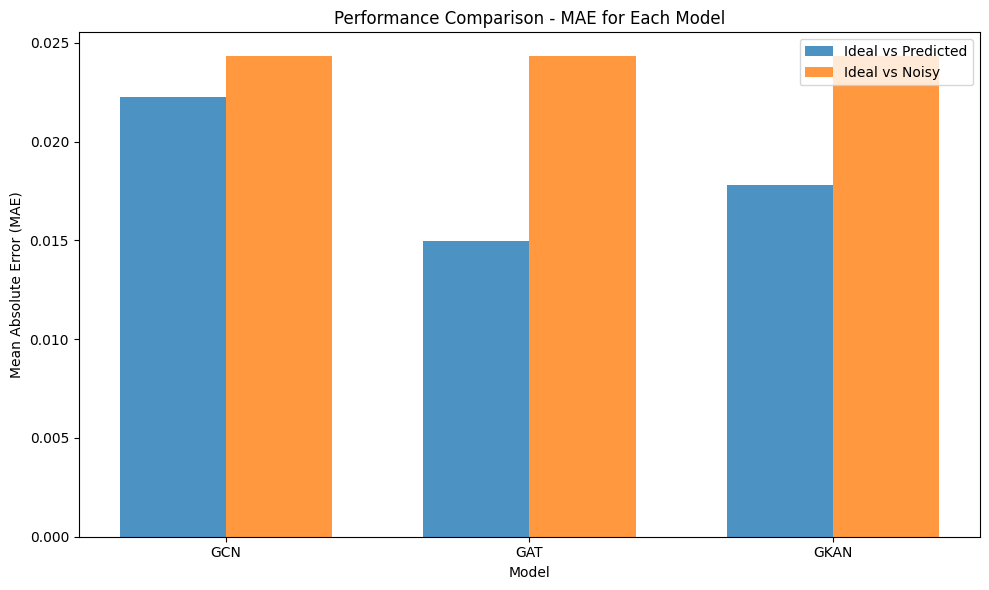

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, GATConv, global_mean_pool
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
import numpy as np
import random

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load your dataset
data_list = torch.load("D:/heisen/IITM/IITM studies/4th year/sem 8/DA6300/QML blackwater/A-Comprehensive-Study-of-ML-Techniques-for-Quantum-Error-Mitigation/hardware/gnn_dataset_20250409_225849.pt", weights_only=False)
if isinstance(data_list, Data):
    data_list = [data_list]

# Split into training and testing sets
train_data, test_data = train_test_split(data_list, test_size=0.2, random_state=42)
train_loader = DataLoader(train_data, batch_size=1, shuffle=True)
test_loader = DataLoader(test_data, batch_size=1)

class GCNModelJoint(nn.Module):
    def __init__(self, node_in, hidden_dim, qubit_dim=127):
        super(GCNModelJoint, self).__init__()
        self.conv1 = GCNConv(node_in, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.lin1 = nn.Linear(hidden_dim + qubit_dim, hidden_dim)
        self.lin2 = nn.Linear(hidden_dim, 1)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        batch = data.batch if hasattr(data, 'batch') else torch.zeros(x.size(0), dtype=torch.long, device=x.device)
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = global_mean_pool(x, batch)
        
        # Use joint_noisy instead of z_noisy
        joint_noisy = data.joint_noisy.view(x.size(0), -1)
        
        # Concatenate the output of the graph convolution and joint_noisy
        x = torch.cat([x, joint_noisy], dim=1)
        return self.lin2(F.relu(self.lin1(x))).squeeze(-1)
    
class GATModelJoint(nn.Module):
    def __init__(self, node_in, hidden_dim, qubit_dim=127, heads=4):
        super(GATModelJoint, self).__init__()
        self.gat1 = GATConv(node_in, hidden_dim, heads=heads)
        self.gat2 = GATConv(hidden_dim * heads, hidden_dim, heads=1)
        self.lin1 = nn.Linear(hidden_dim + qubit_dim, hidden_dim)
        self.lin2 = nn.Linear(hidden_dim, 1)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        batch = data.batch if hasattr(data, 'batch') else torch.zeros(x.size(0), dtype=torch.long, device=x.device)
        x = F.elu(self.gat1(x, edge_index))
        x = F.elu(self.gat2(x, edge_index))
        x = global_mean_pool(x, batch)
        
        # Use joint_noisy instead of z_noisy
        joint_noisy = data.joint_noisy.view(x.size(0), -1)
        
        # Concatenate the output of the graph attention and joint_noisy
        x = torch.cat([x, joint_noisy], dim=1)
        return self.lin2(F.relu(self.lin1(x))).squeeze(-1)

class SplineActivation(nn.Module):
    def __init__(self, in_channels, out_channels, num_knots=10):
        super(SplineActivation, self).__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.num_knots = num_knots
        # Define learnable parameters for the spline
        self.coefficients = nn.Parameter(torch.randn(in_channels, num_knots))
        self.knots = nn.Parameter(torch.linspace(0, 1, num_knots))

    def forward(self, x):
        # Apply spline activation function
        # For simplicity, using a linear interpolation between knots
        x_normalized = (x - x.min()) / (x.max() - x.min() + 1e-6)
        x_expanded = x_normalized.unsqueeze(-1).repeat(1, 1, self.num_knots)
        knots_expanded = self.knots.view(1, 1, -1)
        weights = torch.relu(1 - torch.abs(x_expanded - knots_expanded))
        out = torch.sum(weights * self.coefficients, dim=-1)
        return out

class GKANModel(nn.Module):
    def __init__(self, node_in, hidden_dim, qubit_dim=127, num_knots=10):
        super(GKANModel, self).__init__()
        self.conv1 = GCNConv(node_in, hidden_dim)
        self.spline1 = SplineActivation(hidden_dim, hidden_dim, num_knots)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.spline2 = SplineActivation(hidden_dim, hidden_dim, num_knots)
        self.lin1 = nn.Linear(hidden_dim + qubit_dim, hidden_dim)
        self.lin2 = nn.Linear(hidden_dim, 1)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        batch = data.batch if hasattr(data, 'batch') else torch.zeros(x.size(0), dtype=torch.long, device=x.device)
        x = self.conv1(x, edge_index)
        x = self.spline1(x)
        x = self.conv2(x, edge_index)
        x = self.spline2(x)
        x = global_mean_pool(x, batch)
        joint_noisy = data.joint_noisy.view(x.size(0), -1)
        x = torch.cat([x, joint_noisy], dim=1)
        x = F.relu(self.lin1(x))
        return self.lin2(x).squeeze(-1)


# Training function
def train(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        pred = model(batch)
        target = batch.joint_ideal.to(device)  # Use joint_ideal as the target for joint expectation
        loss = criterion(pred, target)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

# Evaluation function
def evaluate(model, loader):
    model.eval()
    preds, targets, noisies = [], [], []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            pred = model(batch).cpu().numpy()
            target = batch.joint_ideal.cpu().numpy()
            noisy = batch.joint_noisy.view(batch.joint_ideal.shape).cpu().numpy()

            preds.append(pred)
            targets.append(target)
            noisies.append(noisy)

    preds = np.concatenate(preds)
    targets = np.concatenate(targets)
    noisies = np.concatenate(noisies)

    mae_pred = mean_absolute_error(targets, preds)
    mae_noisy = mean_absolute_error(targets, noisies)

    return mae_pred, mae_noisy
# Main pipeline to train and evaluate models
sample_data = train_data[0]
node_in = sample_data.x.shape[1]
qubit_dim = sample_data.joint_noisy.numel()

models = {
    'GCN': GCNModelJoint(node_in, hidden_dim=64, qubit_dim=qubit_dim).to(device),
    'GAT': GATModelJoint(node_in, hidden_dim=64, qubit_dim=qubit_dim).to(device),
    'GKAN': GKANModel(node_in, hidden_dim=64, qubit_dim=qubit_dim).to(device),
}


results = {}

for name, model in models.items():
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()
    print(f"\nTraining {name} model...")
    for epoch in range(1, 51):
        loss = train(model, train_loader, optimizer, criterion)
        if epoch % 10 == 0:
            print(f"Epoch {epoch:03d} | Loss: {loss:.6f}")
    
    mae_pred, mae_noisy = evaluate(model, test_loader)
    results[name] = {'MAE_Pred': mae_pred, 'MAE_Noisy': mae_noisy}

# Display results
print("\nEvaluation Results:")
for name, result in results.items():
    print(f"{name} - MAE (Pred vs Ideal): {result['MAE_Pred']:.6f}, MAE (Noisy vs Ideal): {result['MAE_Noisy']:.6f}")

import matplotlib.pyplot as plt
import numpy as np

model_names = list(results.keys())
mae_pred_values = [results[name]['MAE_Pred'] for name in model_names]
mae_noisy_values = [results[name]['MAE_Noisy'] for name in model_names]

x = np.arange(len(model_names))  # label locations
width = 0.35  # width of the bars

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, mae_pred_values, width, label='Ideal vs Predicted', alpha=0.8)
plt.bar(x + width/2, mae_noisy_values, width, label='Ideal vs Noisy', alpha=0.8)

plt.xlabel('Model')
plt.ylabel('Mean Absolute Error (MAE)')
plt.title('Performance Comparison - MAE for Each Model')
plt.xticks(x, model_names)
plt.legend()
plt.tight_layout()
plt.show()


### **Traditional and Neural Models (XGBoost, Random Forest, RNN, LSTM)**

---

#### **XGBoost** (Extreme Gradient Boosting)
- **Structure**: XGBoost is a tree-based ensemble model that uses boosting to iteratively refine predictions by correcting errors from prior models.  
- **Process**: The input to XGBoost consisted of vectors encoding gate frequencies, discretized gate parameters, and associated noisy expectation values. The model handled the tabular, high-dimensional feature space efficiently.  
- **Effect**: While XGBoost showed promise in structured or simpler circuits, it struggled to generalize to randomly generated circuits. The lack of structural context limited its predictive power in more chaotic or unstructured circuit topologies.

---

#### **Random Forest**
- **Structure**: Random Forest is a bagging-based ensemble of decision trees, offering a stable and interpretable model for regression tasks.  
- **Process**: Circuit features were fed as-is: gate counts, binned parameter values, and hardware noise metadata. The model learned patterns by averaging outputs from randomly sampled decision trees.  
- **Effect**: Performance on random circuits was inconsistent. Although more robust than single trees, the model’s reliance on manually engineered features limited its ability to model the complex behaviors introduced by quantum noise and circuit irregularities.

---

#### **RNN** (Recurrent Neural Network)
- **Structure**: The RNN was designed to model the quantum circuit as a sequence of gate operations, tokenized by gate type and discretized parameter.  
- **Process**: Gate sequences were encoded and passed through RNN layers to capture temporal dependencies. Noisy expectations and readout errors were appended to the final hidden states for prediction.  
- **Effect**: RNNs captured some gate-order effects but struggled with generalization across variable-length and highly entangled random circuits. Tuning input representation (e.g., bin sizes, padding) had significant but inconsistent effects on performance.

---

#### **LSTM** (Long Short-Term Memory Network)
- **Structure**: LSTM is a type of RNN designed to better handle long-term dependencies in sequential data by using gated memory cells.  
- **Process**: Quantum circuit features were reshaped into sequences, where each timestep represented a feature or a binned gate-parameter. These sequences were passed through stacked LSTM layers to capture latent temporal and structural patterns.  
- **Effect**: LSTM models outperformed standard RNNs in capturing dependencies between gates across the circuit. However, performance still degraded on highly irregular circuits due to the lack of explicit structural or topological awareness. LSTMs benefited from regularized training (dropout and early stopping) and showed competitive MAE on structured datasets.

---

### **General Observation for Traditional and Neural Models**
All models here relied on **frequency-based feature engineering**, which included **gate counts**, **binned parameters**, and **hardware noise features**. While these representations offered simplicity and compatibility with tabular models, they **did not capture circuit topology or gate connectivity**, which proved critical in more complex or randomly structured circuits.  

We explored **multiple binning strategies** for parameter discretization, but **no single configuration consistently reduced prediction error**. These models served as useful baselines but were ultimately **limited in expressiveness** compared to structure-aware graph models.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM
from tensorflow.keras.callbacks import EarlyStopping

# ------------------------------
# 1. Data Preparation
# ------------------------------

# Features and target
df = pd.read_csv('/content/processed_data_freq_10_(2, 3, 2)_1000.csv.csv')

X = df.drop(columns=['ideal', 'noisy', 'ZNE_linear_zne', 'ZNE_richardson_zne'])
y = df['ideal'].values
noisy = df['noisy'].values
zne_linear = df['ZNE_linear_zne'].values
zne_richardson = df['ZNE_richardson_zne'].values

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
num_columns = X.shape[1]

# Train-test split
X_train, X_test, y_train, y_test, noisy_test, zne_lin_test, zne_rich_test = train_test_split(
    X_scaled, y, noisy, zne_linear, zne_richardson, test_size=0.2, random_state=42
)

# Track results
results = {}

In [ ]:
# ------------------------------
# 2. LSTM Model
# ------------------------------
X_lstm_train = X_train.reshape((-1, num_columns, 1))
X_lstm_test = X_test.reshape((-1, num_columns, 1))

model_lstm = Sequential([
    LSTM(32, return_sequences=True, input_shape=(num_columns, 1)),
    Dropout(0.3),
    LSTM(16, return_sequences=True),
    Dropout(0.3),
    LSTM(8),
    Dropout(0.2),
    Dense(1, activation='linear')
])
model_lstm.compile(optimizer='adam', loss='mse', metrics=['mae'])
model_lstm.fit(X_lstm_train, y_train, epochs=50, batch_size=64, validation_split=0.2, verbose=0)
y_pred_lstm = model_lstm.predict(X_lstm_test).flatten()
results['LSTM'] = y_pred_lstm

# ------------------------------
# 3. Simple RNN-style Dense Model
# ------------------------------
model_dense = Sequential([
    Dense(32, activation='relu', input_shape=(num_columns,)),
    Dense(16, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='linear')
])
model_dense.compile(optimizer='adam', loss='mse', metrics=['mae'])
model_dense.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2, verbose=0)
y_pred_dense = model_dense.predict(X_test).flatten()
results['Dense'] = y_pred_dense

# ------------------------------
# 4. Random Forest Regressor
# ------------------------------
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
results['Random Forest'] = y_pred_rf

# ------------------------------
# 5. XGBoost Regressor
# ------------------------------
# Convert data to DMatrix (XGBoost's optimized data structure)
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# Define XGBoost parameters
params = {
    'objective': 'reg:squarederror',  # for regression tasks
    'eval_metric': 'mae',  # Mean Absolute Error
    'max_depth': 6,  # depth of tree
    'eta': 0.1,  # learning rate
    'subsample': 0.8,  # subsample ratio
    'colsample_bytree': 0.8,  # feature subsample ratio
    'nthread': 4  # number of threads to use for parallelism
}

# Train the XGBoost model
num_round = 100  # Number of boosting rounds
model_xgb = xgb.train(params, dtrain, num_round)
y_pred_xgb = model_xgb.predict(dtest)
results['XGBoost'] = y_pred_xgb

In [ ]:
# ------------------------------
# 5. Visualization Function
# ------------------------------
def plot_mae_comparison(y_true, y_noisy, y_zne1, y_zne2, y_pred, model_name):
    # --- Noisy vs Prediction ---
    mae_noisy = mean_absolute_error(y_true, y_noisy)
    mae_pred = mean_absolute_error(y_true, y_pred)

    plt.figure(figsize=(7, 4))
    plt.bar(['Noisy', 'Predicted'], [mae_noisy, mae_pred], color=['skyblue', 'salmon'])
    plt.title(f'{model_name} | MAE: Noisy vs Prediction')
    plt.ylabel('MAE')
    for i, val in enumerate([mae_noisy, mae_pred]):
        plt.text(i, val + 0.005, f"{val:.4f}", ha='center', va='bottom')
    plt.tight_layout()
    plt.show()

    # --- ZNEs vs Prediction ---
    mae_zne1 = mean_absolute_error(y_true, y_zne1)
    mae_zne2 = mean_absolute_error(y_true, y_zne2)

    plt.figure(figsize=(7, 4))
    plt.bar(['ZNE Linear', 'ZNE Richardson', 'Predicted'],
            [mae_zne1, mae_zne2, mae_pred], color=['orange', 'lightgreen', 'salmon'])
    plt.title(f'{model_name} | MAE: ZNE vs Prediction')
    plt.ylabel('MAE')
    for i, val in enumerate([mae_zne1, mae_zne2, mae_pred]):
        plt.text(i, val + 0.005, f"{val:.4f}", ha='center', va='bottom')
    plt.tight_layout()
    plt.show()

# ------------------------------
# 6. Plot for All Models
# ------------------------------
for name, pred in results.items():
    plot_mae_comparison(y_test, noisy_test, zne_lin_test, zne_rich_test, pred, name)


### **CNN-Based Model (1D Convolutional Neural Network)**

#### **Model Architecture**
The CNN model consisted of stacked **1D convolutional layers** interleaved with **max-pooling operations**. It was designed to extract sequential patterns and localized gate-feature interactions.

- **Layers**:
  - Multiple `Conv1D` layers to capture feature locality and interactions
  - `MaxPooling1D` layers for downsampling
  - Fully connected dense layers for final regression
  - `Dropout` regularization to prevent overfitting

---

#### **Training Setup**
- **Loss**: Mean Squared Error (MSE)  
- **Metric**: Mean Absolute Error (MAE)  
- **Optimizer**: Adam  
- **Training Epochs**: 50  
- **Batch Size**: 64  
- **Validation Split**: 20% of the training data used for validation  

---

#### **Observation**
The CNN-based architecture attempted to learn relationships between circuit feature sequences and their ideal expectation values. While it captured some local patterns, **performance was inconsistent** across random circuit instances.

The model was **sensitive to how feature vectors were constructed**, and no optimal configuration (e.g., feature ordering or dimensionality) clearly minimized the error.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error

# ===============================
# Load and Prepare Data
# ===============================

# Drop target columns and isolate features and label
X = df.drop(columns=['ideal', 'noisy', 'ZNE_linear_zne', 'ZNE_richardson_zne'])
y = df['ideal'].values
num_columns = X.shape[1]

# Normalize
scaler = StandardScaler()
X = scaler.fit_transform(X.values)

# Reshape for Conv1D input: (samples, timesteps, features)
X = X.reshape((X.shape[0], num_columns, 1))

# Split
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df.index, test_size=0.2, random_state=42
)

# ===============================
# Build CNN Model
# ===============================

model = Sequential([
    Conv1D(filters=32, kernel_size=3, activation='relu', padding='same', input_shape=(num_columns, 1)),
    Conv1D(filters=32, kernel_size=3, activation='relu', padding='same'),
    MaxPooling1D(pool_size=2),

    Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
    Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
    MaxPooling1D(pool_size=2),

    Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
    Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),

    Flatten(),
    Dense(20, activation='relu'),
    Dropout(0.5),
    Dense(20, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='linear')  # Regression output
])

# Compile and Train
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.fit(X_train, y_train, epochs=50, batch_size=64, validation_split=0.2)

# Evaluate
loss, mae = model.evaluate(X_test, y_test, verbose=0)
print(f"Test MAE (Model): {mae:.4f}")

# ===============================
# Baseline Comparisons
# ===============================

# Get true ideal values and model predictions
y_true = df.loc[idx_test, 'ideal'].values
y_pred = model.predict(X_test).flatten()

# Compute MAEs for different methods
mae_noisy       = mean_absolute_error(y_true, df.loc[idx_test, 'noisy'].values)
mae_linear      = mean_absolute_error(y_true, df.loc[idx_test, 'ZNE_linear_zne'].values)
mae_richardson  = mean_absolute_error(y_true, df.loc[idx_test, 'ZNE_richardson_zne'].values)
mae_predicted   = mean_absolute_error(y_true, y_pred)

# ===============================
# Visualization
# ===============================

labels = ['Noisy', 'ZNE Linear', 'ZNE Richardson', 'CNN Prediction']
mae_values = [mae_noisy, mae_linear, mae_richardson, mae_predicted]
colors = ['skyblue', 'orange', 'lightgreen', 'salmon']

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, mae_values, color=colors)

# Add annotations
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.002, f"{yval:.4f}", ha='center', va='bottom', fontsize=9)

plt.title('MAE Comparison with Ideal Expectation Values', fontsize=13)
plt.ylabel('Mean Absolute Error', fontsize=11)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - loss: 0.3778 - mae: 0.4556 - val_loss: 0.3388 - val_mae: 0.4538
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.3376 - mae: 0.4197 - val_loss: 0.3512 - val_mae: 0.4375
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.3654 - mae: 0.4491 - val_loss: 0.3246 - val_mae: 0.4356
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.3293 - mae: 0.4191 - val_loss: 0.3229 - val_mae: 0.4351
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.3531 - mae: 0.4451 - val_loss: 0.3165 - val_mae: 0.4201
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.3162 - mae: 0.4163 - val_loss: 0.3015 - val_mae: 0.4196
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.3149 - mae: 0.4104 - val_loss: 0.2952 - val_mae: 0.4138
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.3209 - mae: 0.4200 - val_loss: 0.2998 - val_mae: 0.4093
Epoch 9/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.2955 - mae: 0.

# 🧠 4-Qubit Ising Circuit: ML-Based Quantum Error Mitigation

## 🧲 What is the Ising Model?

The **Ising model** is a mathematical model in statistical mechanics used to describe the behavior of magnetic spins on a lattice. In quantum computing, the **1D transverse-field Ising model (TFIM)** is commonly studied and has the Hamiltonian:

$$
\hat{H} = -J \sum_j \hat{Z}_j \hat{Z}_{j+1} + h \sum_j \hat{X}_j = -J \hat{H}_{ZZ} + h \hat{H}_X
$$


- **J**: Exchange coupling between neighboring spins  
- **h**: Strength of the transverse magnetic field  
- The model demonstrates quantum phase transitions and captures complex spin dynamics.

---

## ⚙️ The Circuit Setup

The **4-qubit Trotterized Ising circuits** simulate TFIM dynamics using **first-order Trotterization**. Circuit variations are created by:
- Varying **Trotter steps** (depth of time evolution).
- Sampling **J < h** from the paramagnetic phase.

### Data Generation

The data used in this study was already generated and provided in the original research paper **"ML-QEM: Machine Learning-Based Quantum Error Mitigation"** (see reference below). The circuits were generated for structured noise models and measured in Pauli bases. We obtained the data from their [official GitHub repository](https://github.com/qiskit-community/ml-qem) and implemented various **machine learning (ML) models** on it for error mitigation and performance benchmarking.

---

## 🔬 What’s Going On?

In the context of quantum error mitigation, **machine learning (ML)** models are applied to mitigate the effects of noise in quantum circuits. The paper implements and compares several models to the **Zero-Noise Extrapolation (ZNE)** technique.

The experiments included both simulation-based and real hardware-based setups:
- **Noisy Simulations**: The circuits were run on the **FakeLima simulator** with incoherent noise and also with additional coherent errors.
- **IBM Hardware**: The performance of the models was benchmarked on **IBM’s `ibm_algiers`** quantum processor, where both incoherent, coherent, and readout noise were present.

### ML Models Implemented

We implemented the following ML models for quantum error mitigation:
1. **Random Forest Regressor (RFR)**
2. **XGBoost Regressor**
3. **Kolmogorov Arnold Network (KAN)**

### Performance Comparison

- **KAN** performed better than **Random Forest (RF)**, and **RF** outperformed **XGBoost (XGB)** in mitigating noisy quantum circuits, demonstrating the suitability of KNN and RF for this application.
- These models were trained on the noisy data and then tested on unseen circuits, comparing their performance with traditional techniques like **ZNE**.

---

## 📚 Reference

> **Paper Title**: Machine Learning for Practical Quantum Error Mitigation  
> **Authors**: Haoran Liao, Derek S. Wang, Iskandar Sitdikov, et al.  


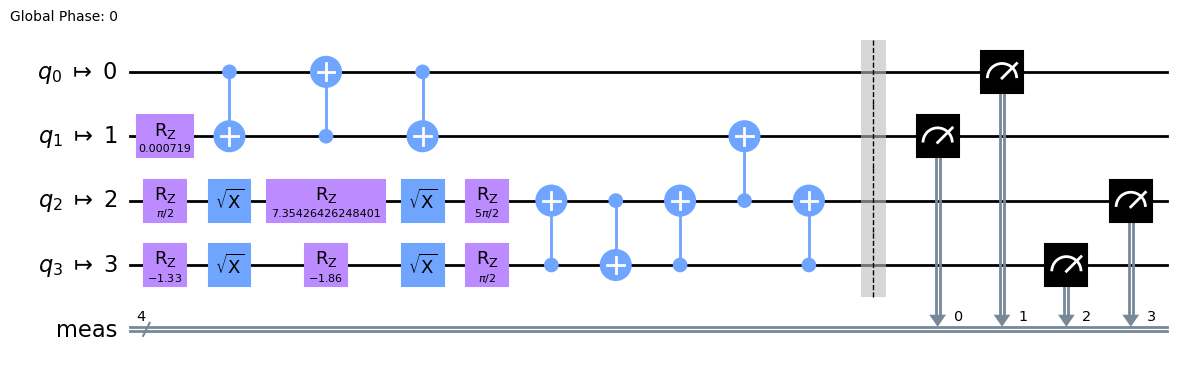

In [ ]:
# ----------------------------
# Load and Unshuffle Data
# ----------------------------
import pickle, json
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import DataLoader, TensorDataset

# Load pickled results
with open('../tutorials/data/ising_init_from_qasm_hardware/shuffled/results.pk', 'rb') as file:
    loaded = pickle.load(file)
noisy_exp_vals = np.array(loaded['noisy'])
zne_mitigated_vals = np.array(loaded['zne_mitigated'])
ideal_exp_vals_estimator = loaded['ideal']

# Reshape noisy and zne mitigated values to shape (samples, 4)
noisy_exp_vals = noisy_exp_vals.reshape(-1, 4).tolist()
zne_mitigated_vals = zne_mitigated_vals.reshape(-1, 4).tolist()

# Load original index order to unshuffle
with open('../tutorials/data/ising_init_from_qasm_hardware/shuffled/index_order.json', 'r') as file:
    index_order = json.load(file)

# Function to unshuffle a list using the saved index order
def unshuffle_list(shuffled_list, index_order):
    unshuffled_list = [None] * len(shuffled_list)
    for i, index in enumerate(index_order):
        unshuffled_list[index] = shuffled_list[i]
    return unshuffled_list  

# Unshuffle the data
noisy_exp_vals = unshuffle_list(noisy_exp_vals, index_order)
zne_mitigated_vals = unshuffle_list(zne_mitigated_vals, index_order)
ideal_exp_vals_estimator = unshuffle_list(ideal_exp_vals_estimator, index_order)  

# Flatten circuit_batches list
all_circuits = []
for circuits in tqdm(circuit_batches):
    for trans_circuit in circuits:
        all_circuits.append(trans_circuit)

# Unshuffle circuits as well
all_circuits_unshuffled = unshuffle_list(all_circuits, index_order)

# ----------------------------
# Create DataFrame and Split by Trotter Step
# ----------------------------

# Accumulate all values and labels grouped by Trotter step
all_ideal, all_noisy, all_zne, all_circuits, all_steps = [], [], [], [], []
for step, i in enumerate(range(0, 2000, 200)):
    all_ideal.extend(ideal_exp_vals_estimator[i:i+200])
    all_noisy.extend(noisy_exp_vals[i:i+200])
    all_zne.extend(zne_mitigated_vals[i:i+200])
    all_circuits.extend(all_circuits_unshuffled[i:i+200])
    all_steps.extend([step]*200)

for step, i in enumerate(range(2000, 3000, 100)):
    all_ideal.extend(ideal_exp_vals_estimator[i:i+100])
    all_noisy.extend(noisy_exp_vals[i:i+100])
    all_zne.extend(zne_mitigated_vals[i:i+100])
    all_circuits.extend(all_circuits_unshuffled[i:i+100])
    all_steps.extend([step]*100)

# Create a DataFrame from all data
rows = list(zip(all_ideal, all_noisy, all_zne, all_circuits, all_steps))
rows = sorted(rows, key=lambda x: x[-1])  # Sort by Trotter step

df = pd.DataFrame(rows, columns=['ideal', 'noisy', 'zne', 'circ', 'step'])

# Custom train-test split per step
train_size_per_step, test_size_per_step = 50, 250
train_rows = df.groupby('step').head(train_size_per_step).reset_index(drop=True)
test_rows = df.groupby('step').tail(test_size_per_step).reset_index(drop=True)

# Extract values
train_ideal, train_noisy, train_zne, train_circuits = list(train_rows['ideal']), list(train_rows['noisy']), list(train_rows['zne']), list(train_rows['circ'])
test_ideal, test_noisy, test_zne, test_circuits = list(test_rows['ideal']), list(test_rows['noisy']), list(test_rows['zne']), list(test_rows['circ'])

# ----------------------------
# Encode Circuits to Features
# ----------------------------

X_train, y_train = encode_data_v2_ecr(train_circuits, train_ideal, train_noisy, obs_size=4, two_q_gate='cx')
X_test, y_test = encode_data_v2_ecr(test_circuits, test_ideal, test_noisy, obs_size=4, two_q_gate='cx')

# Create PyTorch DataLoaders
BATCH_SIZE = 32
train_dataset = TensorDataset(torch.Tensor(X_train), torch.Tensor(y_train))
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

test_dataset = TensorDataset(torch.Tensor(X_test), torch.Tensor(y_test))
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE*1000, shuffle=False)

# Store in DataFrames for tree-based models
X_train = pd.DataFrame(X_train)
y_train = pd.DataFrame(y_train)
X_test = pd.DataFrame(X_test)
y_test = pd.DataFrame(y_test)

# ----------------------------
# Train Tree-Based Models (Random Forest)
# ----------------------------

from sklearn.ensemble import RandomForestRegressor

rfr_tree_list = []
for q in range(4):  # One model per qubit
    rfr = RandomForestRegressor(n_estimators=100)
    rfr.fit(X_train, y_train.iloc[:, q])
    rfr_tree_list.append(rfr)

# ----------------------------
# Evaluate Model and Compute Distances
# ----------------------------

distances = []
num_spins = 4

# Inference on test set
for batch_X, batch_y in test_loader:
    out = []
    for q, model in enumerate(rfr_tree_list):
        out.append(model.predict(batch_X[:, :]))
    out = np.array(out).transpose()

    for ideal, noisy, ngm_mitigated in zip(batch_y.tolist(), batch_X[:, -num_spins:].tolist(), out.tolist()):
        for q in range(num_spins):
            ideal_q = ideal[q]
            noisy_q = noisy[q]
            ngm_mitigated_q = ngm_mitigated[q]
            distances.append({
                f"ideal_{q}": ideal_q,
                f"noisy_{q}": noisy_q,
                f"ngm_mitigated_{q}": ngm_mitigated_q,
                f"dist_noisy_{q}": np.abs(ideal_q - noisy_q),
                f"dist_mitigated_{q}": np.abs(ideal_q - ngm_mitigated_q),
                f"dist_sq_noisy_{q}": np.square(ideal_q - noisy_q),
                f"dist_sq_mitigated_{q}": np.square(ideal_q - ngm_mitigated_q),
            })

# ----------------------------
# Performance and Visualization
# ----------------------------

plt.style.use({'figure.facecolor': 'white'})
df = pd.DataFrame(distances)

# Print per-qubit RMSE
for q in range(num_spins):
    print(f'RMSE_noisy_{q}:', np.sqrt(df[f"dist_sq_noisy_{q}"].mean()))
    print(f'RMSE_mitigated_{q}:', np.sqrt(df[f"dist_sq_mitigated_{q}"].mean()))

# Print overall RMSE
print(f'RMSE_noisy:', np.sqrt(np.mean([df[f"dist_sq_noisy_{q}"].mean() for q in range(num_spins)])))
print(f'RMSE_mitigated:', np.sqrt(np.mean([df[f"dist_sq_mitigated_{q}"].mean() for q in range(num_spins)])))

# Boxplot: Distance from ideal (noisy vs mitigated)
sns.boxplot(
    data=df[
        ["dist_noisy_0", "dist_mitigated_0",
         "dist_noisy_1", "dist_mitigated_1",
         "dist_noisy_2", "dist_mitigated_2",
         "dist_noisy_3", "dist_mitigated_3"]
    ],
    orient="h",
    showfliers=False
)
plt.title("Distance to Ideal Expectation Value")
plt.show()

# Histogram: Value distribution for ideal, noisy, and mitigated (Qubit 0)
sns.histplot(
    [df['ideal_0'], df['noisy_0'], df["ngm_mitigated_0"]],
    kde=True, bins=40
)
plt.title("Expectation Values Distribution (Qubit 0)")
plt.show()


## 📊 9. Results & Evaluation

### 🎯 Accuracy Metrics

- **L2 Error**: Computed between the **mitigated** and **ideal** expectation values.
- **Mean Absolute Error (MAE)**: Averaged across test circuits for each model.

> 💡 L2 error plotting functionality is included in our codebase as a reusable method—users can visualize model performance if desired.  
> While we did not perform a formal runtime-overhead analysis, our experiments consistently showed that ML-based methods are significantly faster than ZNE for the same circuits.

---

### 🔍 Evaluation by Circuit Depth

We present results from quantum circuits of varying depths:

- **Circuits with Low Depth (GNN Results)**  
  Represent circuits with a pre-transpiled depth of 2, typically exhibiting simpler structures.  
  ![results/q10_d2.png](results/q10_d2.png)

- **Circuits with High Depth (GNN Results)**  
  Represent circuits with a pre-transpiled depth of 10, which introduce more complexity in terms of gate operations.  
  ![results/q10_d10.png](results/q10_d10.png)

- **Circuits with Medium Depth (GCN, GAT, GKAN Comparison)**  
  These circuits fall between low and high depths. Here, we compare the performance of GCN, GAT, and GKAN models.  
  ![results/hardware_models.png](results/hardware_models.png)

> ⚠️ After transpiling, we found actual depths ranged from ~400 to ~1000.  
> For consistency, we continue using "low" and "high" based on pre-transpiled depth.

---

### 🧠 Evaluation by Model Type

We present **MAE results** across various quantum error mitigation methods using different model architectures:

- **Artificial Neural Network (ANN)**  
  Demonstrates solid performance on structured input data with fully connected layers.  
  ![ANN MAE Results](results/ann.png)

- **Recurrent Neural Network (RNN)**  
  Captures sequential dependencies in gate-order, suitable for temporal circuit encoding.  
  ![RNN MAE Results](results/rnn.png)

- **Convolutional Neural Network (CNN)**  
  Learns spatial correlations from circuit image encodings.  
  ![CNN MAE Results](results/cnn.png)

- **XGBoost**  
  Efficiently models nonlinear feature interactions using gradient-boosted trees.  
  ![XGBoost MAE Results](results/xgb.png)

- **Random Forest**  
  Uses ensemble decision trees to generalize across circuit feature patterns.  
  ![Random Forest MAE Results](results/rf.png)

---

### 🧪 Evaluation on 4-Qubit Ising Circuits

Tested on **Random Forest**, **XGBoost**, and **KAN** models:

#### • Random Forest
![Results](results/rf1.png)  
![Results](results/rf2.png)

#### • XGBoost
![Results](results/xgb1a.png)  
![Results](results/xgb1b.png)  
![Results](results/xgb1c.png)

#### • KAN
![Results](results/kan1a.png)  
![Results](results/kan1b.png)

---

### 📈 Combined Model Comparison
![Results](results/net1.png)


### 🔍 Key Observations
- **KANs** demonstrated strong potential but required meticulous hyperparameter tuning.
- **GNNs** consistently performed well on circuit-based data due to their ability to leverage graph structures.
- Certain hybrid GNN architectures achieved up to **14× improvement** over ZNE in accuracy (at lower depths).

---

## 🧠 10. Learnings & Challenges

### ✅ What Went Well:
- Gained a deep understanding of the **ML-QEM pipeline** components.
- Improved grasp of **quantum circuit simulation** and **noise modeling** intricacies.

### ⚠️ Challenges:
- We were unable to fully implement the **frequency-based mitigation approach**, which limited the performance of models like **Random Forest** and **XGBoost**. These models rely heavily on hand-crafted features, which the frequency-based method could have supported more effectively.
- CNNs were **difficult to adapt** to spatially encode quantum circuits in a meaningful way.
- As **qubit count and depth increased**, **simulation time** increased drastically, making **scalability testing** difficult.
- For **random quantum circuits**, we observed that **expectation values tend toward zero** with increasing depth. This introduces a training challenge, as simply guessing zero becomes a statistically strong baseline, which can mislead or stagnate model learning.
- The **black-box nature** of both **ML models** and **quantum circuit behavior** made interpretation and debugging particularly challenging.

---

## 📈 GAT Performance Insights

While GCNs and GKANs performed well in various settings, **GAT (Graph Attention Networks)** consistently delivered high accuracy, especially in medium-depth circuits. Several hypotheses for this are:

- **Attention mechanisms** likely helped prioritize influential qubit interactions within deep and noisy circuit topologies.
- GATs dynamically weigh neighbor contributions, which may help mitigate irrelevant or noisy signal propagation, a common issue in real quantum hardware simulations.
- Their **adaptive receptive field** nature might enable better generalization across circuits with varying structural complexity.

---

## 🏁 11. Conclusion

Our project successfully reproduced and extended the ML-QEM framework by:

- Reviewing and implementing **Machine Learning based quantum error mitigation strategies**.
- Generating datasets using **realistic noise models** (e.g., IBM Brisbane backend).
- Designing and evaluating **novel model architectures**, including **KANs**, **CNNs**, and **GATs**.

The results affirm that **ML-QEM** is a **promising and scalable** approach to quantum error mitigation, especially when tailored with **architecture-specific adaptations**.

---

## 🔮 12. Next Steps

- Explore **transformer-based models** for encoding circuit structure and gate sequences.
- Investigate **hybrid classical-quantum models** that might improve extrapolation in high-depth circuit regimes.
- Develop **robust preprocessing and feature extraction pipelines** to better handle frequency-based mitigation and traditional ensemble models.

---

## 📁 Disclaimer

> ⚠️ **Note**: The code provided in this repository serves primarily as **demonstrative snippets**. Some parts may not run out-of-the-box due to the absence of large pre-generated datasets. However, corresponding Jupyter notebooks within each folder are designed to regenerate the necessary data via simulation. Please refer to the **Introduction section** for guidance on running the notebooks in the correct order.
